## CHIRPS Ingestion, Preprocessing, and QC

## Import Python Packages 

In [3]:
import os
import warnings
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regionmask
import xarray as xr

d:\VECTRI_MODEL\.VECTRI2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup: Imports, Working Directory, and Paths

In [4]:
p = Path(r"D:\VECTRI_MODEL")
os.chdir(p)
print(Path.cwd())


D:\VECTRI_MODEL


## Set Paths & Directories

In [5]:
PATH_CHIRPS = Path("data/chirps_ethiopia_p25/chirps_ethiopia_1993-2025_p25_clip.nc")

REPORT_DIR = Path("reports/qc_chirps")
FIG_DIR    = REPORT_DIR / "figures"
PROC_DIR   = Path("data/processed/chirps")
ANCILLARY  = Path("data/ancillary/grid_mask")
OUT_DIR    = Path("data/processed/chirps")
OUTPUT_DIR = Path("data/processed/climatology")
CLIM_FIG   = Path("outputs/figures/climatology")

for d in (REPORT_DIR, FIG_DIR, PROC_DIR, ANCILLARY,
          OUT_DIR, OUTPUT_DIR, CLIM_FIG):
    d.mkdir(parents=True, exist_ok=True)

print("PATH_CHIRPS  :", PATH_CHIRPS.resolve())
print("ANCILLARY    :", ANCILLARY.resolve())
print("OUT_DIR      :", OUT_DIR.resolve())
print()
print("CHIRPS data exists:", PATH_CHIRPS.exists())



PATH_CHIRPS  : D:\VECTRI_MODEL\data\chirps_ethiopia_p25\chirps_ethiopia_1993-2025_p25_clip.nc
ANCILLARY    : D:\VECTRI_MODEL\data\ancillary\grid_mask
OUT_DIR      : D:\VECTRI_MODEL\data\processed\chirps

CHIRPS data exists: True


## Load Raw CHIRPS

In [6]:
chirps_raw = xr.open_dataset(PATH_CHIRPS)
chirps_raw

<xarray.Dataset> Size: 131MB
Dimensions:  (time: 11322, lat: 48, lon: 60)
Coordinates:
  * time     (time) datetime64[ns] 91kB 1993-01-01 1993-01-02 ... 2025-12-31
  * lat      (lat) float32 192B 3.125 3.375 3.625 3.875 ... 14.38 14.62 14.88
  * lon      (lon) float32 240B 33.12 33.38 33.62 33.88 ... 47.38 47.62 47.88
Data variables:
    precip   (time, lat, lon) float32 130MB ...
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2015-10-07
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given day.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/chg/products/CH...
    website:           http://chg.geog.ucsb.edu/data/chirps/index.html
    faq:               http://chg-wiki.geog.ucsb.edu/wiki/CHIRPS_FAQ

## Basic Information

In [7]:
print("BASIC DATASET INFORMATION")
print("-" * 60)
print(f"Title        : {chirps_raw.attrs.get('title',   'N/A')}")
print(f"Source       : {chirps_raw.attrs.get('source',  'N/A')}")
print(f"Version      : {chirps_raw.attrs.get('version', 'N/A')}")
ref = str(chirps_raw.attrs.get('reference', 'N/A'))
print(f"Reference    : {ref[:90]}{'...' if len(ref)>90 else ''}")
print(f"\nTime range   : {chirps_raw.time.min().values}  →  "
      f"{chirps_raw.time.max().values}")
print(f"Time steps   : {len(chirps_raw.time)}")

BASIC DATASET INFORMATION
------------------------------------------------------------
Title        : CHIRPS Version 2.0
Source       : N/A
Version      : Version 2.0
Reference    : Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros, D.H., Verdin, J.P., Rowland, J.D., ...

Time range   : 1993-01-01T00:00:00.000000000  →  2025-12-31T00:00:00.000000000
Time steps   : 11322


## Data Variables    

In [8]:
print("DATA VARIABLES")
print("-" * 60)
for var_name, da in chirps_raw.data_vars.items():
    print(f"Variable      : {var_name}")
    print(f"Long name     : {da.attrs.get('long_name',     'N/A')}")
    print(f"Standard name : {da.attrs.get('standard_name', 'N/A')}")
    print(f"Units         : {da.attrs.get('units',         'N/A')}")
    print(f"Shape         : {da.shape}")
    print(f"dtype         : {da.dtype}")
    print("-" * 40)

main_var = list(chirps_raw.data_vars.keys())[0]
print(f"\n→ Main variable: {main_var}")


DATA VARIABLES
------------------------------------------------------------
Variable      : precip
Long name     : Climate Hazards group InfraRed Precipitation with Stations
Standard name : convective precipitation rate
Units         : mm/day
Shape         : (11322, 48, 60)
dtype         : float32
----------------------------------------

→ Main variable: precip


## Grid Information

In [9]:
print("GRID & SPATIAL INFORMATION")
print("-" * 60)

lat_dim = "lat"  if "lat"  in chirps_raw.coords else "latitude"
lon_dim = "lon"  if "lon"  in chirps_raw.coords else "longitude"
lat     = chirps_raw[lat_dim].values
lon     = chirps_raw[lon_dim].values

print(f"Latitude  range     : {lat.min():.4f}° → {lat.max():.4f}°")
print(f"Latitude  resolution: {abs(np.diff(lat).mean()):.4f}°")
print(f"Longitude range     : {lon.min():.4f}° → {lon.max():.4f}°")
print(f"Longitude resolution: {abs(np.diff(lon).mean()):.4f}°")
print(f"Grid size           : {lat.size} × {lon.size}")
print(f"Spatial resolution  : 0.25° (CHIRPS p25)")


GRID & SPATIAL INFORMATION
------------------------------------------------------------
Latitude  range     : 3.1250° → 14.8750°
Latitude  resolution: 0.2500°
Longitude range     : 33.1250° → 47.8750°
Longitude resolution: 0.2500°
Grid size           : 48 × 60
Spatial resolution  : 0.25° (CHIRPS p25)


## Global Attributes    

In [10]:
print("GLOBAL ATTRIBUTES")
print("-" * 60)
for key, value in chirps_raw.attrs.items():
    vs = str(value)
    print(f"• {key:<22}: {vs[:90]}{'...' if len(vs)>90 else ''}")

GLOBAL ATTRIBUTES
------------------------------------------------------------
• Conventions           : CF-1.6
• title                 : CHIRPS Version 2.0
• history               : created by Climate Hazards Group
• version               : Version 2.0
• date_created          : 2015-10-07
• creator_name          : Pete Peterson
• creator_email         : pete@geog.ucsb.edu
• institution           : Climate Hazards Group.  University of California at Santa Barbara
• documentation         : http://pubs.usgs.gov/ds/832/
• reference             : Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros, D.H., Verdin, J.P., Rowland, J.D., ...
• comments              :  time variable denotes the first day of the given day.
• acknowledgements      : The Climate Hazards Group InfraRed Precipitation with Stations development process was car...
• ftp_url               : ftp://chg-ftpout.geog.ucsb.edu/pub/org/chg/products/CHIRPS-latest/
• website               : http://chg.geog.ucsb.edu/data/chirps/

## Build Ethiopia Target Grid (0.25°)

In [11]:
res     = 0.25
lat_min, lat_max = 3.0, 15.5
lon_min, lon_max = 33.0, 48.5

target_lat = np.round(np.arange(lat_min - res/2, lat_max + res/2, res), 4)
target_lon = np.round(np.arange(lon_min - res/2, lon_max + res/2, res), 4)

print(f"Target grid  : {target_lat.size} × {target_lon.size}")
print(f"Lat range    : {target_lat.min():.4f} → {target_lat.max():.4f}")
print(f"Lon range    : {target_lon.min():.4f} → {target_lon.max():.4f}")
print(f"Resolution   : {res}°")


Target grid  : 51 × 63
Lat range    : 2.8750 → 15.3750
Lon range    : 32.8750 → 48.3750
Resolution   : 0.25°


## Regrid Raw CHIRPS to Target Grid

In [12]:
print("Regridding to target grid...")

# Normalise dim names
rename_map = {}
if "lat" in chirps_raw.coords and "latitude"  not in chirps_raw.coords:
    rename_map["lat"] = "latitude"
if "lon" in chirps_raw.coords and "longitude" not in chirps_raw.coords:
    rename_map["lon"] = "longitude"
if rename_map:
    chirps_raw = chirps_raw.rename(rename_map)

main_var = list(chirps_raw.data_vars.keys())[0]

out = chirps_raw[[main_var]].interp(
    latitude=target_lat,
    longitude=target_lon,
    method="linear",
)

out.attrs.update(chirps_raw.attrs)
out.attrs["title"]      = "CHIRPS on Ethiopia target grid (masked)"
out.attrs["regridding"] = ("xarray linear interp — "
                            "document conservative alternative for production")

out["latitude"].attrs.update({
    "standard_name": "latitude",  "long_name": "latitude",
    "units": "degrees_north",     "axis": "Y",
})
out["longitude"].attrs.update({
    "standard_name": "longitude", "long_name": "longitude",
    "units": "degrees_east",      "axis": "X",
})
out["time"].attrs.update({"standard_name": "time", "axis": "T"})

print("Regridded dataset:")
print(out)

Regridding to target grid...
Regridded dataset:
<xarray.Dataset> Size: 291MB
Dimensions:    (time: 11322, latitude: 51, longitude: 63)
Coordinates:
  * time       (time) datetime64[ns] 91kB 1993-01-01 1993-01-02 ... 2025-12-31
  * latitude   (latitude) float64 408B 2.875 3.125 3.375 ... 14.88 15.12 15.38
  * longitude  (longitude) float64 504B 32.88 33.12 33.38 ... 47.88 48.12 48.38
Data variables:
    precip     (time, latitude, longitude) float64 291MB nan nan nan ... nan nan
Attributes: (12/16)
    Conventions:       CF-1.6
    title:             CHIRPS on Ethiopia target grid (masked)
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2015-10-07
    creator_name:      Pete Peterson
    ...                ...
    comments:           time variable denotes the first day of the given day.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pu

## Build & Apply Ethiopia Land Mask

In [13]:
ne_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
print("Loading countries from:", ne_url)
world = gpd.read_file(ne_url)
eth = world[world.ADMIN == "Ethiopia"].to_crs(4326)

print(f"Ethiopia geometry loaded: {len(eth)} feature(s)")

eth_mask_obj = regionmask.Regions(
    outlines=list(eth.geometry),
    names=["Ethiopia"],
    abbrevs=["ETH"],
)

mask_2d = eth_mask_obj.mask(out["longitude"], out["latitude"])
mask_da = (mask_2d == 0)   # True = inside Ethiopia

out = out.where(mask_da)
print(f"Mask applied — {int(mask_da.values.sum())} land pixels retained")

Loading countries from: https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip
Ethiopia geometry loaded: 1 feature(s)
Mask applied — 1486 land pixels retained


## Plot Mask Check  

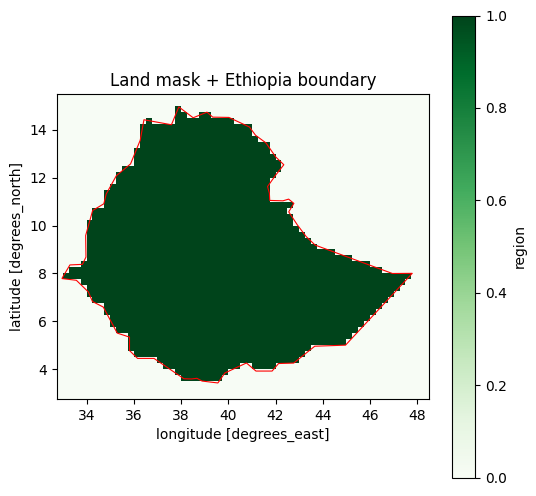

Saved: data\ancillary\grid_mask\mask_check.png


In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
mask_da.plot(ax=ax, cmap="Greens", add_colorbar=True)
eth.boundary.plot(ax=ax, edgecolor="red", linewidth=0.8)
ax.set_title("Land mask + Ethiopia boundary")
fig.savefig(ANCILLARY / "mask_check.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved:", ANCILLARY / "mask_check.png")


## Export Land Mask

In [15]:
grid_ds = xr.Dataset(
    {"land_mask": mask_da},
    attrs={
        "title":               "Ethiopia target grid and land mask",
        "grid_resolution_deg": str(res),
        "notes": "Coastal pixels included if centroid in polygon.",
    },
)
out_nc = ANCILLARY / "ethiopia_target_grid_mask.nc"
grid_ds.to_netcdf(out_nc, encoding={"land_mask": {"zlib": True, "complevel": 3}})
print("Saved NetCDF:", out_nc)

readme = ANCILLARY / "ethiopia_domain_README.md"
readme.write_text(
    "# Ethiopia domain assumptions\n\n"
    "- Boundary: Natural Earth 110m (simplified).\n"
    "- Mask: regionmask from polygon; verify coastal/lake pixels visually.\n"
    "- Disputed areas: follow your institution policy.\n",
    encoding="utf-8",
)
print("Saved README:", readme)

Saved NetCDF: data\ancillary\grid_mask\ethiopia_target_grid_mask.nc
Saved README: data\ancillary\grid_mask\ethiopia_domain_README.md


## Save Masked Dataset

In [16]:
ver      = "v1.0"
tmin_str = pd.Timestamp(out.time.values[0]).strftime("%Y%m%d")
tmax_str = pd.Timestamp(out.time.values[-1]).strftime("%Y%m%d")
out.attrs["processing_version"] = ver

fp  = OUT_DIR / f"chirps_ethiopia_masked_{tmin_str}_{tmax_str}_{ver}.nc"
enc = {main_var: {"zlib": True, "complevel": 3}}
out.to_netcdf(fp, encoding=enc)
print("Full masked dataset saved:")
print(f"  {fp}")
print(f"  Dimensions: {dict(out.dims)}")

Full masked dataset saved:
  data\processed\chirps\chirps_ethiopia_masked_19930101_20251231_v1.0.nc
  Dimensions: {'time': 11322, 'latitude': 51, 'longitude': 63}


C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_23968\1981622740.py:11: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(out.dims)}")


## Subset to Kiremt Season (Jun-Sep)

In [20]:
print("\nSubsetting to June-September (Kiremt season window)...")

ds_kiremt = out.sel(time=out.time.dt.month.isin([6, 7, 8, 9]))   # ← FIX

print(f"Original time steps  : {len(out.time)}")
print(f"After Jun-Sep subset : {len(ds_kiremt.time)}")
print(f"Time range           : "
      f"{pd.Timestamp(ds_kiremt.time.values[0]).date()} → "
      f"{pd.Timestamp(ds_kiremt.time.values[-1]).date()}")


Subsetting to June-September (Kiremt season window)...
Original time steps  : 11322
After Jun-Sep subset : 3782
Time range           : 1993-06-01 → 2025-09-30


## Calibration / Validation Split

In [21]:
def split_periods(ds_in: xr.Dataset) -> dict[str, xr.Dataset]:
    return {
        "cal": ds_in.sel(time=slice("1993-01-01", "2016-12-31")),
        "val": ds_in.sel(time=slice("2017-01-01", "2025-12-31")),
        "ops": ds_in.sel(time=slice("2026-01-01", "2040-12-31")),
    }

parts = split_periods(ds_kiremt)   # ← FIX: Kiremt-only split

print("Cal/Val/Ops split (Kiremt season days only):")
for k, sub in parts.items():
    n = len(sub.time)
    if n > 0:
        t0 = pd.Timestamp(sub.time.values[0]).date()
        t1 = pd.Timestamp(sub.time.values[-1]).date()
        print(f"  {k:3}  {n:5} daily steps   {t0} → {t1}")
    else:
        print(f"  {k:3}      0 daily steps   (no data)")

# Expected:
#   cal   2886 steps   1993-02-01 → 2016-05-31
#   val   1082 steps   2017-02-01 → 2025-05-31
#   ops      0 steps

Cal/Val/Ops split (Kiremt season days only):
  cal   2684 daily steps   1993-06-01 → 2016-09-30
  val   1098 daily steps   2017-06-01 → 2025-09-30
  ops      0 daily steps   (no data)


## Kiremt Seasonal Climatologies

In [23]:
print("Computing Kiremt seasonal climatologies...")

for period_name, sub_ds in parts.items():
    print(f"\nProcessing {period_name.upper()} period...")
    if len(sub_ds.time) == 0:
        print(f"  ⚠️  No data for {period_name}")
        continue

    yearly_totals = (
        sub_ds[main_var]
        .resample(time="YE")
        .sum(skipna=True)
    )
    n_seasons  = int((yearly_totals > 0).any(dim=["latitude", "longitude"]).sum())
    mean_total = float(yearly_totals.mean())

    print(f"  {period_name:<10} → {n_seasons} Kiremt seasons | "
          f"Mean seasonal total: {mean_total:.1f} mm")

    clim_mean = yearly_totals.mean(dim="time").to_dataset(name="kiremt_precip_mean")
    clim_mean.attrs = sub_ds.attrs.copy()
    clim_mean.attrs.update({
        "title": f"Kiremt seasonal precipitation climatology ({period_name})",
        "climatology_period": (
            f"{pd.Timestamp(sub_ds.time.values[0]).year}"
            f"–{pd.Timestamp(sub_ds.time.values[-1]).year}"
        ),
    })

    clim_path = PROC_DIR / f"chirps_kiremt_climatology_{period_name}.nc"
    clim_mean.to_netcdf(
        clim_path,
        encoding={"kiremt_precip_mean": {"zlib": True, "complevel": 3}},
    )
    print(f"  ✅ Saved: {clim_path.name}")

Computing Kiremt seasonal climatologies...

Processing CAL period...
  cal        → 22 Kiremt seasons | Mean seasonal total: 202.9 mm
  ✅ Saved: chirps_kiremt_climatology_cal.nc

Processing VAL period...
  val        → 9 Kiremt seasons | Mean seasonal total: 213.0 mm
  ✅ Saved: chirps_kiremt_climatology_val.nc

Processing OPS period...
  ⚠️  No data for ops


## Save Kiremt Split Datasets

In [25]:
enc_split = {main_var: {"zlib": True, "complevel": 3}}
print(f"--- Saving Belg split datasets to {OUT_DIR} ---")

for period, sub_ds in parts.items():
    if len(sub_ds.time) == 0:
        print(f"Skipping {period}: no data.")
        continue

    tmin_sub = pd.Timestamp(sub_ds.time.values[0]).strftime("%Y%m%d")
    tmax_sub = pd.Timestamp(sub_ds.time.values[-1]).strftime("%Y%m%d")

    sub_ds.attrs["processing_version"]  = ver
    sub_ds.attrs["data_subset"]         = period
    sub_ds.attrs["time_coverage_start"] = str(sub_ds.time.values[0])
    sub_ds.attrs["time_coverage_end"]   = str(sub_ds.time.values[-1])

    out_path = OUT_DIR / f"chirps_ethiopia_{period}_{tmin_sub}_{tmax_sub}_{ver}.nc"
    print(f"Saving {period:3} : {len(sub_ds.time):6} steps → {out_path.name}")
    sub_ds.to_netcdf(out_path, encoding=enc_split)

print("\nAll subsets saved.")

--- Saving Belg split datasets to data\processed\chirps ---
Saving cal :   2645 steps → chirps_ethiopia_cal_19930201_20160531_v1.0.nc
Saving val :   1082 steps → chirps_ethiopia_val_20170201_20250531_v1.0.nc
Skipping ops: no data.

All subsets saved.


## Format & Save VECTRI-Ready Datasets

In [26]:
def prepare_for_vectri(ds_in: xr.Dataset) -> xr.Dataset:
    """
    Standardise to match VECTRI example_sys5.nc structure:
      - Rename precip variable → tp
      - Rename lat/lon        → latitude/longitude
      - Standardise CF metadata
    """
    ds_v  = ds_in.copy()
    pvar  = list(ds_v.data_vars.keys())[0]
    if pvar != "tp":
        ds_v = ds_v.rename({pvar: "tp"})

    ds_v["tp"].attrs.update({
        "long_name":     "Total precipitation",
        "standard_name": "convective precipitation rate",
        "units":         "mm/day",
        "time_step":     "day",
        "missing_value": np.float32(-32767.0),   # CF attr — kept in attrs
    })

    rn = {}
    if "lat" in ds_v.coords and "latitude"  not in ds_v.coords: rn["lat"] = "latitude"
    if "lon" in ds_v.coords and "longitude" not in ds_v.coords: rn["lon"] = "longitude"
    if rn:
        ds_v = ds_v.rename(rn)

    ds_v["latitude"].attrs.update({
        "standard_name": "latitude",  "long_name": "latitude",
        "units": "degrees_north",     "axis": "Y",
    })
    ds_v["longitude"].attrs.update({
        "standard_name": "longitude", "long_name": "longitude",
        "units": "degrees_east",      "axis": "X",
    })
    ds_v["time"].attrs.update({
        "standard_name": "time", "long_name": "time", "axis": "T",
    })
    return ds_v


# _FillValue lives only in encoding (prevents xarray CFMaskCoder ValueError)
vectri_encoding = {
    "tp": {
        "dtype":      "float32",
        "_FillValue": np.float32(-32767.0),
        "zlib":       True,
        "complevel":  3,
    },
    "time":      {"dtype": "float64",
                  "units": "hours since 1900-01-01 00:00:00.0",
                  "calendar": "standard"},
    "latitude":  {"dtype": "float32"},
    "longitude": {"dtype": "float32"},
}

# Remove stale full-year files from earlier runs
stale_files = [
    OUT_DIR / "chirps_ethiopia_cal_vectri_19930101_20161231.nc",
    OUT_DIR / "chirps_ethiopia_val_vectri_20170101_20251231.nc",
]
for sf in stale_files:
    if sf.exists():
        os.remove(sf)
        print(f"Removed stale file: {sf.name}")

print("--- Formatting and saving VECTRI-ready datasets ---")
for period, sub_ds in parts.items():
    if len(sub_ds.time) == 0:
        print(f"  {period:3} : skipped (no data)")
        continue

    v_ds = prepare_for_vectri(sub_ds)
    v_ds["tp"].attrs.pop("_FillValue", None)   # must not be in attrs

    tmin_v = pd.Timestamp(v_ds.time.values[0]).strftime("%Y%m%d")
    tmax_v = pd.Timestamp(v_ds.time.values[-1]).strftime("%Y%m%d")

    v_path = OUT_DIR / f"chirps_ethiopia_{period}_vectri_{tmin_v}_{tmax_v}.nc"
    v_ds.to_netcdf(v_path, encoding=vectri_encoding)
    print(f"  {period:3} : {len(v_ds.time):5} steps → {v_path.name}")

# Expected:
#   cal : 2886 steps → chirps_ethiopia_cal_vectri_19930201_20160531.nc
#   val : 1082 steps → chirps_ethiopia_val_vectri_20170201_20250531.nc

--- Formatting and saving VECTRI-ready datasets ---
  cal :  2645 steps → chirps_ethiopia_cal_vectri_19930201_20160531.nc
  val :  1082 steps → chirps_ethiopia_val_vectri_20170201_20250531.nc
  ops : skipped (no data)


## Format & Save VECTRI-Ready Datasets

In [27]:
print("=" * 62)
print("VERIFICATION — re-open exported VECTRI files")
print("=" * 62)

cal_path = OUT_DIR / "chirps_ethiopia_cal_vectri_19930201_20160531.nc"
val_path = OUT_DIR / "chirps_ethiopia_val_vectri_20170201_20250531.nc"

for label, fpath in [("CAL", cal_path), ("VAL", val_path)]:
    if not fpath.exists():
        print(f"\n  {label}: FILE NOT FOUND — {fpath.name}")
        continue
    ds_c = xr.open_dataset(fpath)
    t0   = pd.Timestamp(ds_c.time.values[0]).date()
    t1   = pd.Timestamp(ds_c.time.values[-1]).date()
    print(f"\n  {label}: {fpath.name}")
    print(f"    Dimensions : {dict(ds_c.dims)}")
    print(f"    Time range : {t0} → {t1}")
    print(f"    Variables  : {list(ds_c.data_vars)}")
    print(f"    Lat range  : {float(ds_c.latitude.min()):.4f} → "
          f"{float(ds_c.latitude.max()):.4f}")
    print(f"    Lon range  : {float(ds_c.longitude.min()):.4f} → "
          f"{float(ds_c.longitude.max()):.4f}")
    print(f"    tp units   : {ds_c['tp'].attrs.get('units','?')}")
    print(f"    FillValue  : {ds_c['tp'].encoding.get('_FillValue','?')}")
    ds_c.close()

# Expected:
#   CAL: time=2886  lat=52  lon=66   1993-02-01 → 2016-05-31
#   VAL: time=1082  lat=52  lon=66   2017-02-01 → 2025-05-31

VERIFICATION — re-open exported VECTRI files

  CAL: chirps_ethiopia_cal_vectri_19930201_20160531.nc
    Dimensions : {'time': 2645, 'latitude': 51, 'longitude': 63}
    Time range : 1993-02-01 → 2016-05-31
    Variables  : ['tp']


C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2764811527.py:16: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"    Dimensions : {dict(ds_c.dims)}")


    Lat range  : 2.8750 → 15.3750
    Lon range  : 32.8750 → 48.3750
    tp units   : mm/day
    FillValue  : -32767.0

  VAL: chirps_ethiopia_val_vectri_20170201_20250531.nc
    Dimensions : {'time': 1082, 'latitude': 51, 'longitude': 63}
    Time range : 2017-02-01 → 2025-05-31
    Variables  : ['tp']
    Lat range  : 2.8750 → 15.3750
    Lon range  : 32.8750 → 48.3750
    tp units   : mm/day
    FillValue  : -32767.0


C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2764811527.py:16: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"    Dimensions : {dict(ds_c.dims)}")


## NaN-Pixel Diagnosis (lake pixels)

In [ ]:
ds_cal_c = xr.open_dataset(PROC_DIR / "chirps_kiremt_climatology_cal.nc")
clim     = ds_cal_c["kiremt_precip_mean"]
nan_mask = np.isnan(clim.values)
n_nan    = int(nan_mask.sum())

print("=" * 60)
print("DIAGNOSIS — NaN pixels in Kiremt climatology (CAL)")
print("=" * 60)
print(f"  Total NaN pixels : {n_nan}")

if n_nan == 0:
    print("""
  No NaN pixels in the stored climatology file.
  resample().sum(skipna=True) produced finite values everywhere —
  lake pixels received values via linear interpolation during
  CHIRPS regridding.  White holes in the raw contourf plot came
  from NaN in the daily data; fill_lake_nans() resolves this.
""")
else:
    nan_lats = clim["latitude"].values[nan_mask.any(axis=1)]
    nan_lons = clim["longitude"].values[nan_mask.any(axis=0)]
    print(f"  NaN lat range : {nan_lats.min():.2f}°N → {nan_lats.max():.2f}°N")
    print(f"  NaN lon range : {nan_lons.min():.2f}°E → {nan_lons.max():.2f}°E")
    lats_2d    = np.tile(clim["latitude"].values[:, None],
                         (1, clim["longitude"].size))
    lons_2d    = np.tile(clim["longitude"].values[None, :],
                         (clim["latitude"].size, 1))
    nan_coords = list(zip(lats_2d[nan_mask], lons_2d[nan_mask]))
    print("\n  NaN pixel centres:")
    for la, lo in sorted(nan_coords):
        print(f"    ({la:.2f}°N, {lo:.2f}°E)")

ds_cal_c.close()

DIAGNOSIS — NaN pixels in Belg climatology (CAL)
  Total NaN pixels : 0

  No NaN pixels in the stored climatology file.
  resample().sum(skipna=True) produced finite values everywhere —
  lake pixels received values via linear interpolation during
  CHIRPS regridding.  White holes in the raw contourf plot came
  from NaN in the daily data; fill_lake_nans() resolves this.



## Fill_lake_nans Helper 

In [29]:
def fill_lake_nans(da: xr.DataArray) -> xr.DataArray:
    """
    Fill NaN pixels (open-water / lake pixels where CHIRPS has
    no data) by 2-D linear interpolation from land neighbours.

    Two-pass approach — average longitude-pass and latitude-pass
    results for a symmetric fill.  Only originally-NaN pixels
    are modified; no NetCDF files are changed.
    """
    filled_lon = da.interpolate_na(
        dim="longitude", method="linear", fill_value="extrapolate"
    )
    filled_lat = da.interpolate_na(
        dim="latitude",  method="linear", fill_value="extrapolate"
    )
    filled = (filled_lon + filled_lat) / 2.0
    return da.where(da.notnull(), other=filled)

## Kiremt Climatology Comparison Plot

C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2141443962.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.13, 1, 0.95])


✅ Plot saved → outputs\figures\climatology\belg_climatology_cal_vs_val_final.png


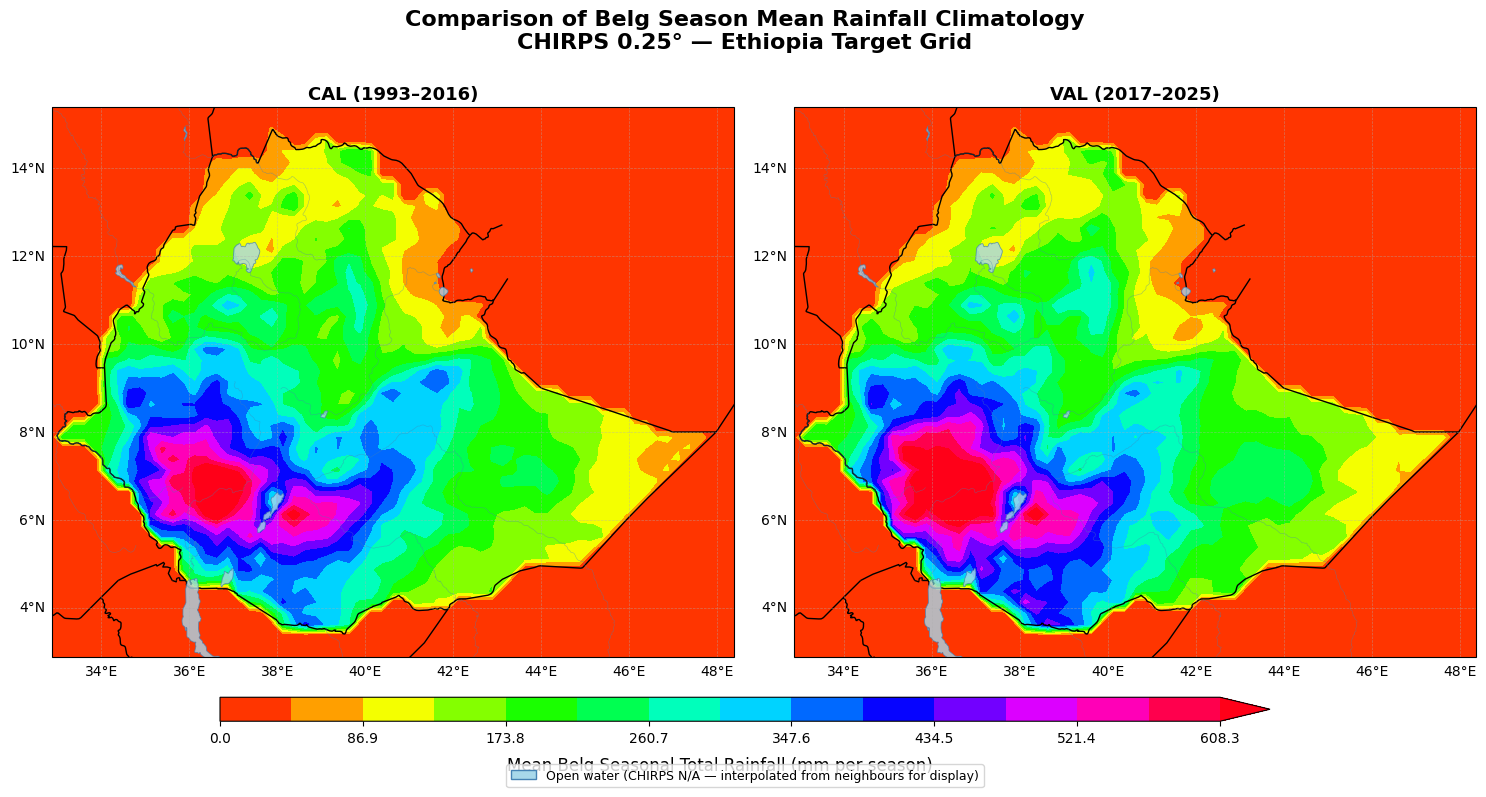

In [ ]:
cal_clim_path = PROC_DIR / "chirps_kiremt_climatology_cal.nc"
val_clim_path = PROC_DIR / "chirps_kiremt_climatology_val.nc"

if not cal_clim_path.exists() or not val_clim_path.exists():
    print("Climatology files not found — run Cell 17 first.")
else:
    ds_cal = xr.open_dataset(cal_clim_path)
    ds_val = xr.open_dataset(val_clim_path)

    # Fill lake NaN pixels for plotting only
    cal_filled = fill_lake_nans(ds_cal["kiremt_precip_mean"])
    val_filled = fill_lake_nans(ds_val["kiremt_precip_mean"])

    # Shared colour scale
    all_vals = np.concatenate([
        cal_filled.values[np.isfinite(cal_filled.values)],
        val_filled.values[np.isfinite(val_filled.values)],
    ])
    vmin   = 0.0
    vmax   = float(np.nanpercentile(all_vals, 99))
    levels = np.linspace(vmin, vmax, 15)

    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(1, 2, figsize=(15, 8),
                             subplot_kw={"projection": proj})

    for ax, da_filled, title in zip(
        axes,
        [cal_filled, val_filled],
        ["CAL (1993–2016)", "VAL (2017–2025)"],
    ):
        im = ax.contourf(
            da_filled["longitude"],
            da_filled["latitude"],
            da_filled,
            levels=levels,
            cmap="hsv",
            transform=proj,
            extend="max",
        )

        ax.add_feature(cfeature.BORDERS,
                       linewidth=1.0, edgecolor="black")
        ax.add_feature(cfeature.LAND,
                       facecolor="lightgray", alpha=0.05)
        ax.add_feature(cfeature.LAKES,
                       facecolor="#a8d8ea", alpha=0.8,
                       edgecolor="steelblue", linewidth=0.6)
        ax.add_feature(cfeature.RIVERS,
                       edgecolor="steelblue", linewidth=0.4, alpha=0.5)

        ax.set_title(title, fontsize=13, fontweight="bold")

        gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                          alpha=0.5, linestyle="--")
        gl.top_labels   = False
        gl.right_labels = False

    # Shared colorbar
    cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.03])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal",
                        extend="max", ticks=levels[::2])
    cbar.set_label("Mean Kiremt Seasonal Total Rainfall (mm per season)",
                   fontsize=12, labelpad=8)
    cbar.ax.tick_params(labelsize=10)

    # Open-water legend entry
    lake_patch = mpatches.Patch(
        facecolor="#a8d8ea", edgecolor="steelblue",
        label="Open water (CHIRPS N/A — interpolated from neighbours for display)",
    )
    fig.legend(
        handles=[lake_patch],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.01),
        fontsize=9,
        framealpha=0.8,
    )

    fig.suptitle(
        "Comparison of Kiremt Season Mean Rainfall Climatology\n"
        "CHIRPS 0.25° — Ethiopia Target Grid",
        fontsize=16, fontweight="bold", y=0.97,
    )
    plt.tight_layout(rect=[0, 0.13, 1, 0.95])

    save_path = CLIM_FIG / "kiremt_climatology_cal_vs_val_final.png"
    plt.savefig(save_path, dpi=350, bbox_inches="tight", facecolor="white")
    print(f"✅ Plot saved → {save_path}")
    plt.show()

    ds_cal.close()
    ds_val.close()

## Fill Sanity Check  

In [ ]:
def _lake_label(lat: float, lon: float) -> str:
    """Return the nearest known lake name for a lat/lon."""
    lakes = {
        "Lake Abaya":   (6.30, 37.90),
        "Lake Chamo":   (5.84, 37.56),
        "Lake Turkana": (4.00, 36.00),
        "Lake Ziway":   (7.92, 38.82),
        "Lake Shala":   (7.47, 38.57),
        "Lake Langano": (7.60, 38.73),
        "Lake Hawassa": (7.05, 38.46),
    }
    best, best_d = "unknown water body", 999.0
    for name, (la, lo) in lakes.items():
        d = ((lat - la) ** 2 + (lon - lo) ** 2) ** 0.5
        if d < best_d:
            best, best_d = name, d
    return best if best_d < 1.0 else "unknown water body"


ds_cal_c = xr.open_dataset(PROC_DIR / "chirps_kiremt_climatology_cal.nc")
orig     = ds_cal_c["kiremt_precip_mean"]
filled   = fill_lake_nans(orig)

changed  = orig.isnull() & filled.notnull()
n_filled = int(changed.values.sum())

print("\nFill sanity check (CAL climatology):")
print(f"  Original NaN pixels : {int(orig.isnull().values.sum())}")
print(f"  Pixels filled       : {n_filled}")
print(f"  Remaining NaN       : {int(filled.isnull().values.sum())}")

if n_filled > 0:
    lats_f = filled["latitude"].values
    lons_f = filled["longitude"].values
    lat2d  = np.tile(lats_f[:, None], (1, lons_f.size))
    lon2d  = np.tile(lons_f[None, :], (lats_f.size, 1))
    ch     = changed.values
    print("\n  Filled pixel details:")
    for la, lo, val in zip(lat2d[ch], lon2d[ch], filled.values[ch]):
        print(f"    ({la:.2f}°N, {lo:.2f}°E) → {val:.1f} mm  "
              f"[{_lake_label(la, lo)}]")
else:
    print("\n  No NaN pixels needed filling.")
    print("  White holes came from NaN in raw daily data, not in the mean.")

ds_cal_c.close()



Fill sanity check (CAL climatology):
  Original NaN pixels : 0
  Pixels filled       : 0
  Remaining NaN       : 0

  No NaN pixels needed filling.
  White holes came from NaN in raw daily data, not in the mean.


# Fill Sanity Check       

In [33]:
print("\nFinal file inventory — data/processed/chirps/")
print("-" * 65)
for f in sorted(OUT_DIR.glob("*.nc")):
    ds_tmp  = xr.open_dataset(f)
    dims    = dict(ds_tmp.dims)
    size_mb = f.stat().st_size / 1024**2
    ds_tmp.close()
    print(f"  {f.name:<55}  {dims}  {size_mb:.1f} MB")


Final file inventory — data/processed/chirps/
-----------------------------------------------------------------
  chirps_belg_climatology_cal.nc                           {'latitude': 51, 'longitude': 63}  0.0 MB
  chirps_belg_climatology_val.nc                           {'latitude': 51, 'longitude': 63}  0.0 MB


C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2846329636.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dims    = dict(ds_tmp.dims)
C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2846329636.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dims    = dict(ds_tmp.dims)
C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2846329636.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Datas

  chirps_ethiopia_cal_19930101_20161231_v1.0.nc            {'time': 8035, 'lat': 52, 'lon': 66}  24.0 MB
  chirps_ethiopia_cal_19930201_20160531_v1.0.nc            {'time': 2645, 'latitude': 51, 'longitude': 63}  6.4 MB
  chirps_ethiopia_cal_vectri_19930201_20160531.nc          {'time': 2645, 'latitude': 51, 'longitude': 63}  5.9 MB


C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2846329636.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dims    = dict(ds_tmp.dims)
C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2846329636.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dims    = dict(ds_tmp.dims)
C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2846329636.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Datas

  chirps_ethiopia_masked_19930101_20251231_v1.0.nc         {'time': 11322, 'latitude': 51, 'longitude': 63}  28.4 MB
  chirps_ethiopia_val_20170101_20251231_v1.0.nc            {'time': 3287, 'lat': 52, 'lon': 66}  11.2 MB
  chirps_ethiopia_val_20170201_20250531_v1.0.nc            {'time': 1082, 'latitude': 51, 'longitude': 63}  3.0 MB
  chirps_ethiopia_val_vectri_20170201_20250531.nc          {'time': 1082, 'latitude': 51, 'longitude': 63}  2.7 MB


C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2846329636.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dims    = dict(ds_tmp.dims)
C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2846329636.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  dims    = dict(ds_tmp.dims)
C:\Users\DELL 3090\AppData\Local\Temp\ipykernel_12272\2846329636.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Datas